In [3]:
# Download the GEO dataset archive (update URL as needed)
download.file("https://ftp.ncbi.nlm.nih.gov/geo/series/GSE271nnn/GSE271112/suppl/GSE271112_Raw_gene_counts_matrix.txt.gz",
              destfile = "GSE271112_Raw_gene_counts_matrix.txt.gz", mode = "wb")
expr_matrix <- read.delim(gzfile("GSE271112_Raw_gene_counts_matrix.txt.gz"))

In [4]:
# Check the structure of the data
dim(expr_matrix)  # Dimensions of the dataset
head(expr_matrix)  # Preview the first few rows and columns

[1] 25702    10

,id,AN0.1,AN0.2,AN0.3,AN1.1,AN1.2,AN1.3,AN2.1,AN2.2,AN2.3
,<chr>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>
1,16R,1087,1886,2791,1498,607,1579,1456,1507,1485
2,34G,11152,15130,18864,10190,6380,11160,8206,11395,7647
3,35G,5320,5437,6606,3918,2514,4452,4374,5644,2928
4,AAP2,1380,235,1070,384,194,680,2470,628,1822
5,ACO1,499,136,585,177,163,175,742,307,1051
6,ACO2,184,217,349,150,113,258,1409,967,1831


In [5]:
expr_matrix <- expr_matrix[rowSums(expr_matrix > 1) >= 3, ]
dim(expr_matrix)  # Check the new dimensions

[1] 23946    10

In [6]:
expr_matrix <- expr_matrix[rowSums(expr_matrix > 1) >= 3, ]
dim(expr_matrix)  # Check the new dimensions

[1] 23946    10

In [11]:
rownames(expr_matrix) <- expr_matrix[,1]
expr_matrix <- expr_matrix[,-1]
expr_matrix <- apply(expr_matrix, 2, as.numeric)
expr_matrix_log <- log2(expr_matrix + 1)

In [15]:
# remove genes with NA or zero variance
gene_var <- apply(expr_matrix_log, 1, var, na.rm = TRUE)

expr_matrix_log_filtered <- expr_matrix_log[gene_var > 0, ]

pca_result <- prcomp(t(expr_matrix_log_filtered), scale. = TRUE)

In [16]:
# View summary of PCA result
summary(pca_result)

Importance of components:
                           PC1     PC2     PC3     PC4      PC5       PC6
Standard deviation     96.1993 79.2957 60.0631 53.6080 43.37620 3.426e-13
Proportion of Variance  0.3871  0.2630  0.1509  0.1202  0.07871 0.000e+00
Cumulative Proportion   0.3871  0.6502  0.8011  0.9213  1.00000 1.000e+00

In [18]:
# Convert PCA results to a data frame
pca_df <- as.data.frame(pca_result$x)

sample_labels <- rep(c("AN0","AN1","AN2"), each = 2)
pca_df$Condition <- sample_labels[1:nrow(pca_df)]

# Add labels to PCA data frame
pca_df$Condition <- sample_labels

# Preview the data
head(pca_df)


,PC1,PC2,PC3,PC4,PC5,PC6,Condition
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
AN1.1,-93.30679,28.367924,29.064047,-56.24673,57.592310,2.788048e-13,AN0
AN1.2,-1.38071,129.103549,-4.411514,65.73703,-3.513848,2.921274e-13,AN0
AN1.3,-37.70374,11.417912,-58.702780,-55.05009,-61.075439,2.918360e-13,AN1
AN2.1,73.20281,-64.653190,-81.817215,21.08924,41.435549,5.631086e-13,AN1
AN2.2,-90.88738,-98.072238,45.264945,51.66457,-21.585569,-4.889006e-13,AN2
AN2.3,150.07581,-6.163957,70.602517,-27.19403,-12.853002,-9.610368e-14,AN2


In [19]:
if (!requireNamespace("BiocManager", quietly = TRUE))
    install.packages("BiocManager")
BiocManager::install("ggplot2")

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

'getOption("repos")' replaces Bioconductor standard repositories, see
'help("repositories", package = "BiocManager")' for details.
Replacement repositories:
    CRAN: https://cran.rstudio.com

Bioconductor version 3.22 (BiocManager 1.30.27), R 4.5.2 (2025-10-31)

Installing package(s) 'BiocVersion', 'ggplot2'

Old packages: 'base64enc', 'broom', 'bslib', 'cluster', 'cpp11', 'data.table',
  'DBI', 'dbplyr', 'dplyr', 'dtplyr', 'foreign', 'fs', 'gargle', 'ggplot2',
  'highr', 'httr', 'later', 'lattice', 'lubridate', 'openssl', 'pkgload',
  'ragg', 'rappdirs', 'readr', 'shiny', 'systemfonts', 'textshaping',
  'timechange', 'uuid', 'vctrs', 'viridisLite', 'vroom', 'xfun', 'xml2',
  'xtable'



In [20]:
library(ggplot2)

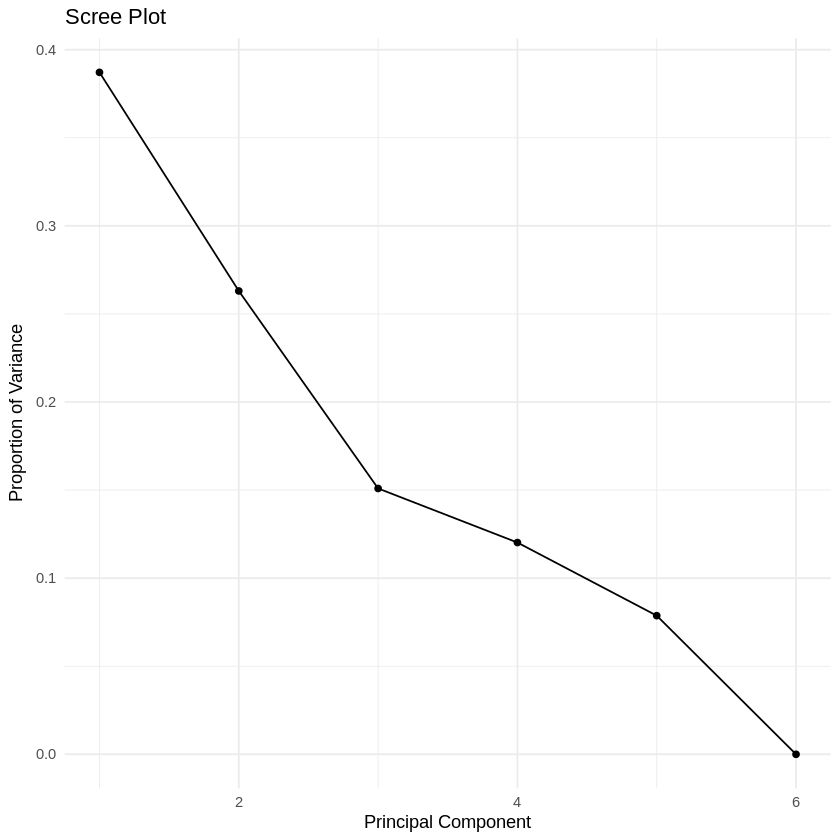

In [21]:
scree_data <- data.frame(
  PC = 1:length(pca_result$sdev),
  Variance = (pca_result$sdev^2) / sum(pca_result$sdev^2)
)
ggplot(scree_data, aes(x = PC, y = Variance)) +
  geom_line() +
  geom_point() +
  theme_minimal() +
  labs(title = "Scree Plot", x = "Principal Component", y = "Proportion of Variance")

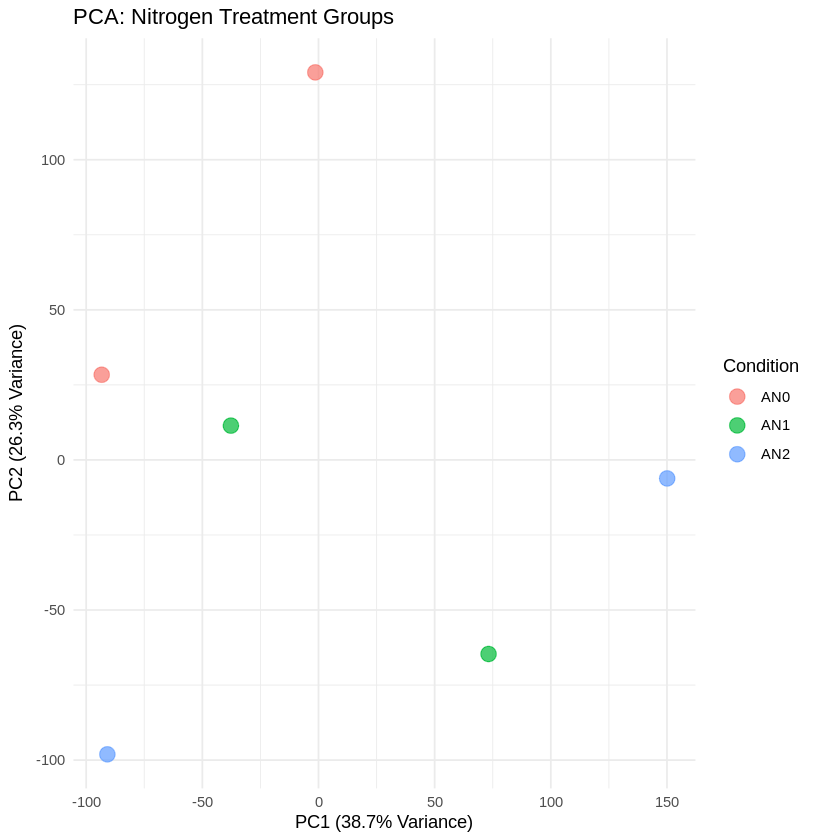

In [22]:
# PCA scatter plot
ggplot(pca_df, aes(x = PC1, y = PC2, color = Condition)) +
  geom_point(size = 4, alpha = 0.7) +  # Size and transparency of points
  theme_minimal() +  # Clean theme
  labs(title = "PCA: Nitrogen Treatment Groups",
       x = paste0("PC1 (", round(summary(pca_result)$importance[2, 1] * 100, 1), "% Variance)"),
       y = paste0("PC2 (", round(summary(pca_result)$importance[2, 2] * 100, 1), "% Variance)"))


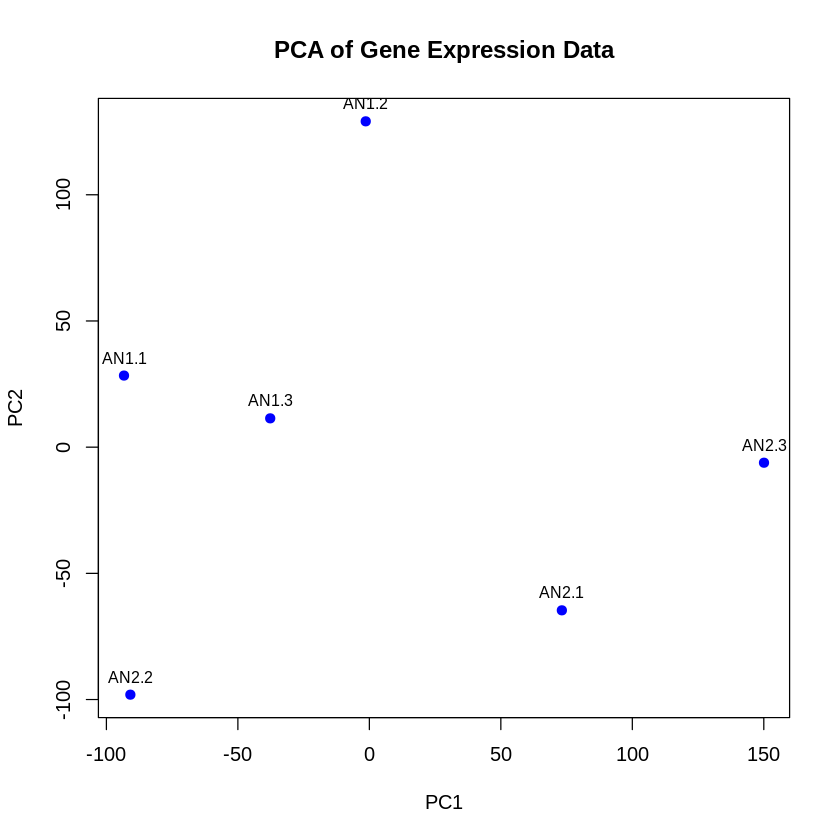

In [23]:
# Basic PCA scatter plot using base R
plot(pca_result$x[,1], pca_result$x[,2],
     xlab = "PC1", ylab = "PC2",
     main = "PCA of Gene Expression Data",
     col = "blue", pch = 19)  # Blue points with solid circles

# Adding sample labels to the plot
text(pca_result$x[,1], pca_result$x[,2], labels = colnames(expr_matrix), pos = 3, cex = 0.8)


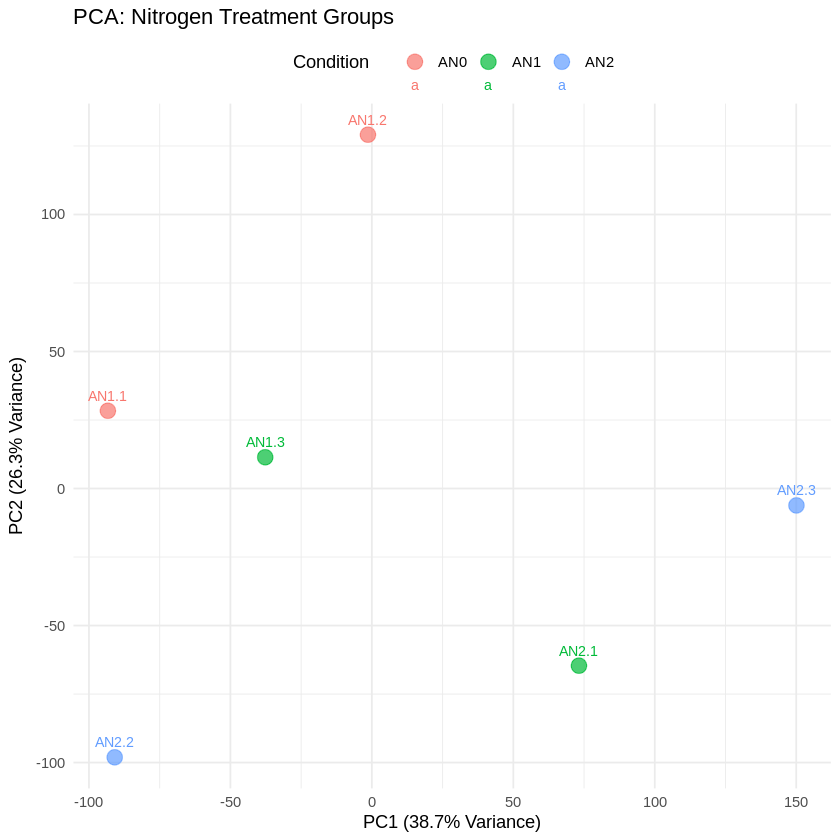

In [24]:
library(ggplot2)

# Create PCA data frame
pca_df <- data.frame(PC1 = pca_result$x[,1],
                     PC2 = pca_result$x[,2],
                     Sample = colnames(expr_matrix),
                     Condition = factor(sample_labels))  # Replace 'sample_labels' with actual conditions

# PCA plot with sample labels
ggplot(pca_df, aes(x = PC1, y = PC2, color = Condition)) +
  geom_point(size = 4, alpha = 0.7) +  # Scatter plot with large, semi-transparent points
  geom_text(aes(label = Sample), vjust = -1, size = 3) +  # Sample labels slightly above points
  theme_minimal() +  # Clean theme
  labs(title = "PCA: Nitrogen Treatment Groups",
       x = paste0("PC1 (", round(summary(pca_result)$importance[2, 1] * 100, 1), "% Variance)"),
       y = paste0("PC2 (", round(summary(pca_result)$importance[2, 2] * 100, 1), "% Variance)")) +
  theme(legend.position = "top")  # Move legend to top


Warning message:
“`aes_string()` was deprecated in ggplot2 3.0.0.
ℹ Please use tidy evaluation idioms with `aes()`.
ℹ See also `vignette("ggplot2-in-packages")` for more information.”


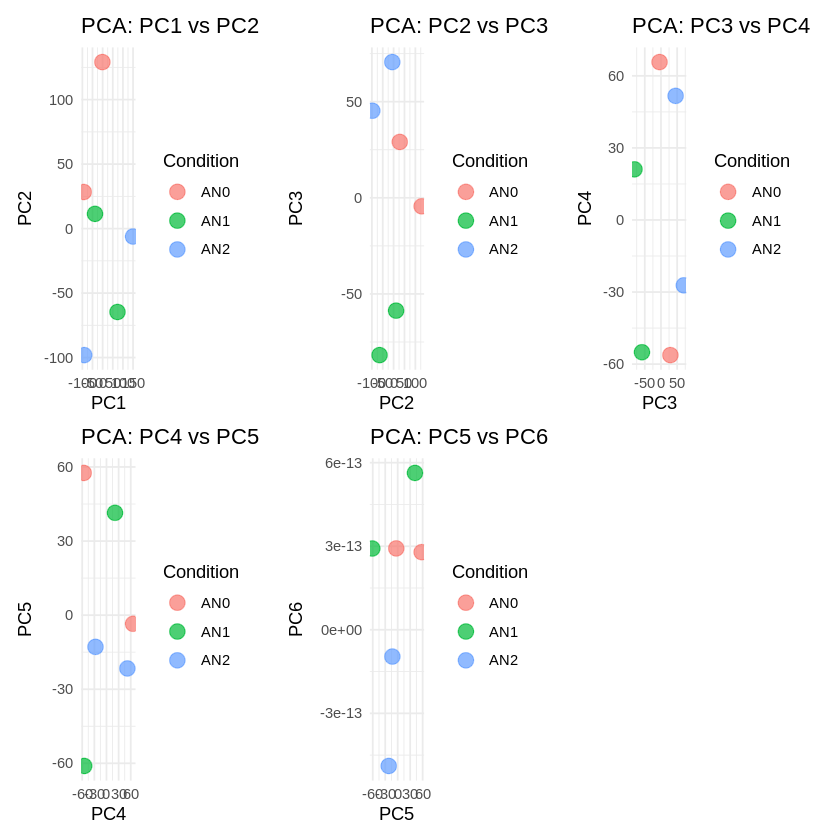

In [28]:
# Load libraries
library(ggplot2)
library(patchwork)

# Convert PCA scores to dataframe
pca_df <- as.data.frame(pca_result$x)

# Add sample names
pca_df$Sample <- rownames(pca_result$x)

# Add condition labels (make sure length matches samples)
pca_df$Condition <- factor(sample_labels)

# Function to create PCA plots
create_pca_plot <- function(x, y) {
  ggplot(pca_df, aes_string(x = x, y = y, color = "Condition")) +
    geom_point(size = 4, alpha = 0.7) +
    theme_minimal() +
    labs(title = paste("PCA:", x, "vs", y))
}

# Detect number of PCs automatically
num_pc <- ncol(pca_result$x)

# Generate PCA plots
pca_plots <- list()
for (i in 1:(num_pc-1)) {
  pca_plots[[i]] <- create_pca_plot(paste0("PC", i), paste0("PC", i+1))
}

# Combine plots
combined_plot <- wrap_plots(pca_plots)

# Show plot
print(combined_plot)

# Save figure
ggsave("combined_pca_plot.png", combined_plot, width = 12, height = 10, dpi = 300)

In [29]:
# Install required packages (only needed once)
install.packages("BiocManager")
BiocManager::install("DESeq2")
BiocManager::install("EnhancedVolcano")  # For visualization

# Load libraries
library(DESeq2)
library(EnhancedVolcano)
library(ggplot2)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

'getOption("repos")' replaces Bioconductor standard repositories, see
'help("repositories", package = "BiocManager")' for details.
Replacement repositories:
    CRAN: https://cran.rstudio.com

Bioconductor version 3.22 (BiocManager 1.30.27), R 4.5.2 (2025-10-31)

Installing package(s) 'DESeq2'

also installing the dependencies ‘XVector’, ‘formatR’, ‘abind’, ‘SparseArray’, ‘lambda.r’, ‘futile.options’, ‘Seqinfo’, ‘S4Arrays’, ‘DelayedArray’, ‘futile.logger’, ‘snow’, ‘BH’, ‘S4Vectors’, ‘IRanges’, ‘GenomicRanges’, ‘SummarizedExperiment’, ‘BiocGenerics’, ‘Biobase’, ‘BiocParallel’, ‘matrixStats’, ‘locfit’, ‘MatrixGenerics’, ‘RcppArmadillo’


Old packages: 'base64enc', 'broom', 'bslib', 'cluster', 'cpp11', 'data.table',
  'DBI', 'dbplyr', 'dplyr', 'dtplyr', 'foreign', 'fs', 'gargle', 'ggplot2',
  'highr', 'httr', 'later', 'lattice', 'lubridate', 'openssl', 'pkgload',
  'ragg', 'rappdirs', 'readr', 'shiny', 'sys

In [54]:
# Load data from the uploaded CSV file
potato_dataset <- read.csv("C:/data/GSE271112_Raw_gene_counts_matrix.txt", header = TRUE, row.names = 1, sep='\t')

Warning message in file(file, "rt"):
“cannot open file 'C:/data/GSE271112_Raw_gene_counts_matrix.txt': No such file or directory”


ERROR: Error in file(file, "rt"): cannot open the connection
